In [135]:
import numpy as np
import matplotlib.pyplot as plt  
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
import pandas as pd 

# Questão 01

### Funções auxiliares

In [136]:
class StandardScaler:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0) + 1e-9  

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [137]:
kc2 = np.loadtxt("kc2.csv", delimiter=",", skiprows=1)

In [138]:
def train_test_split(X, y, test_size=0.2, seed=42):
    n = X.shape[0]
    indices = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(indices)

    split = int(n * (1 - test_size))
    train_idx = indices[:split]
    test_idx = indices[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [139]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [140]:
def mahalanobis_distance(a, b, VI):
    diff = a - b
    return np.sqrt(np.dot(np.dot(diff.T, VI), diff))

In [141]:
def confusion_matrix_elements(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    return TP, TN, FP, FN

In [142]:
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

In [143]:
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    if (TP + FP) == 0:
        return 0
    return TP / (TP + FP)

In [144]:
def recall(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_elements(y_true, y_pred)
    if (TP + FN) == 0:
        return 0
    return TP / (TP + FN)

In [145]:
def f1_score_manual(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    
    if (p + r) == 0:
        return 0
    return 2 * (p * r) / (p + r)

In [146]:
X = kc2[:, :21]

y = kc2[:, 21]
y = y.astype(int)

### Letra A

In [147]:
class KNN:
    def __init__(self, k=3, distance='euclidean'):
        self.k = k
        self.distance = distance
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
        if self.distance == 'mahalanobis':
            cov_matrix = np.cov(X.T)
            self.VI = np.linalg.pinv(cov_matrix)
    
    def _distance(self, a, b):
        if self.distance == 'euclidean':
            return euclidean_distance(a, b)
        elif self.distance == 'mahalanobis':
            return mahalanobis_distance(a, b, self.VI)
    
    def predict(self, X):
        predictions = []
        
        for x in X:
            distances = []
            
            for x_train in self.X_train:
                dist = self._distance(x, x_train)
                distances.append(dist)
            
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            
            most_common = Counter(k_labels).most_common(1)
            predictions.append(most_common[0][0])
        
        return np.array(predictions)

### Letra B

In [148]:
def evaluate_model(model, X, y, kf):
    accs, precs, recs, f1s = [], [], [], []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        accs.append(accuracy(y_test, y_pred))
        precs.append(precision(y_test, y_pred))
        recs.append(recall(y_test, y_pred))
        f1s.append(f1_score_manual(y_test, y_pred))
    
    return {
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
        "precision_mean": np.mean(precs),
        "precision_std": np.std(precs),
        "recall_mean": np.mean(recs),
        "recall_std": np.std(recs),
        "f1_mean": np.mean(f1s),
        "f1_std": np.std(f1s),
    }

In [149]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = {}

In [150]:
configs = [
    ("KNN_k1_euclidean", KNN(k=1, distance='euclidean')),
    ("KNN_k5_euclidean", KNN(k=5, distance='euclidean')),
    ("KNN_k1_mahalanobis", KNN(k=1, distance='mahalanobis')),
    ("KNN_k5_mahalanobis", KNN(k=5, distance='mahalanobis')),
]

In [151]:
for name, model in configs:
    print(f"Rodando: {name}")
    results[name] = evaluate_model(model, X, y, kf)

Rodando: KNN_k1_euclidean
Rodando: KNN_k5_euclidean
Rodando: KNN_k1_mahalanobis
Rodando: KNN_k5_mahalanobis


In [152]:
tree_configs = [
    ("DecisionTree_gini", DecisionTreeClassifier(criterion='gini', random_state=42)),
    ("DecisionTree_entropy", DecisionTreeClassifier(criterion='entropy', random_state=42)),
]

In [153]:
for name, model in tree_configs:
    print(f"Rodando: {name}")
    results[name] = evaluate_model(model, X, y, kf)

Rodando: DecisionTree_gini
Rodando: DecisionTree_entropy


In [154]:
df_results = pd.DataFrame(results).T
print(df_results)

                      accuracy_mean  accuracy_std  precision_mean  \
KNN_k1_euclidean           0.792641      0.059014        0.809747   
KNN_k5_euclidean           0.788528      0.071776        0.799872   
KNN_k1_mahalanobis         0.712987      0.063713        0.737410   
KNN_k5_mahalanobis         0.746537      0.070168        0.816865   
DecisionTree_gini          0.751299      0.080956        0.775137   
DecisionTree_entropy       0.746970      0.108417        0.778534   

                      precision_std  recall_mean  recall_std   f1_mean  \
KNN_k1_euclidean           0.095050     0.776407    0.103214  0.786258   
KNN_k5_euclidean           0.109836     0.783028    0.124763  0.781952   
KNN_k1_mahalanobis         0.101968     0.645937    0.097195  0.685716   
KNN_k5_mahalanobis         0.151156     0.646947    0.124357  0.709779   
DecisionTree_gini          0.120456     0.728648    0.157454  0.735743   
DecisionTree_entropy       0.128510     0.720201    0.187242  0.730215  

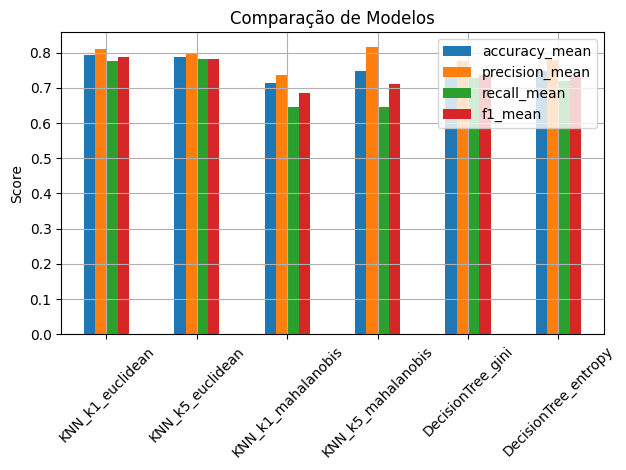

In [155]:
df_plot = df_results[[
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean"
]]

df_plot.plot(kind="bar")

plt.title("Comparação de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [156]:
df_results.sort_values(by="f1_mean", ascending=False)

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
KNN_k1_euclidean,0.792641,0.059014,0.809747,0.095050,0.776407,0.103214,0.786258,0.061941
KNN_k5_euclidean,0.788528,0.071776,0.799872,0.109836,0.783028,0.124763,0.781952,0.081661
DecisionTree_gini,0.751299,0.080956,0.775137,0.120456,0.728648,0.157454,0.735743,0.092714
DecisionTree_entropy,0.746970,0.108417,0.778534,0.128510,0.720201,0.187242,0.730215,0.126258
KNN_k5_mahalanobis,0.746537,0.070168,0.816865,0.151156,0.646947,0.124357,0.709779,0.099263
KNN_k1_mahalanobis,0.712987,0.063713,0.737410,0.101968,0.645937,0.097195,0.685716,0.089631


In [157]:
best_model = df_results["f1_mean"].idxmax()
print("Melhor modelo:", best_model)

Melhor modelo: KNN_k1_euclidean
